Example Plots for Simulated Annealing

In [276]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [277]:
# Parameters
brute_force_data_paths = [
    'data/brute_force/candidate_space_1048576_instances_1_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_9_seed_2026-03-28_15-16-30.csv',
]
boundss = [
    [(0, 2)] * 10
] * len(brute_force_data_paths)

num_runs = 2

# I think init and end temperatures should be chosen dependent on the delta of the energy,
# i.e. delta = new_loss - old_loss (in the exponent)
# larger delta -> larger temperature (and conversely smaller beta)
init_temp = 1000
end_temp = 1
max_temp_iterations = 101

In [278]:
import pandas as pd
import numpy as np

brute_force_data = [pd.read_csv(p) for p in brute_force_data_paths]
loss_spaces = np.array([data['loss'] for data in brute_force_data])

In [279]:
from cl_optimizer import SimulatedAnnealing
sim_annss = [[
        SimulatedAnnealing(
        lookup_table=data,
        bounds=bounds,
    ) for _ in range(num_runs)
] for data, bounds in zip(brute_force_data, boundss, strict=True)]

In [280]:
from joblib import Parallel, delayed
from parallelization import construct_parallelization_arg_list, get_execute_sim_ann

resultss = []
for sim_anns in sim_annss:
    arg_list = construct_parallelization_arg_list(sim_anns, depth=max_temp_iterations, step=10, batch_size=8)

    print(f"Preparing to execute {len(arg_list)} in parallel.")
    results = np.array(
        Parallel(n_jobs=-1, verbose=11)(
        delayed(get_execute_sim_ann(init_temp, end_temp, ))(s_id, sim_ann, temp_iterations) for (s_id, sim_ann), temp_iterations in arg_list)
    )

    resultss.append(results)

Preparing to execute 2 in parallel.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   50.0s
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   50.1s finished


Preparing to execute 2 in parallel.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   45.3s
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   45.6s finished


In [281]:
result_tensor = np.stack(resultss, axis=0).squeeze()

In [282]:
indices = np.argsort(result_tensor[..., 1], axis=2) # sort by temp. iterations (parallelization does not guarantee order)
indices_expanded = np.expand_dims(indices, axis=-1)
result_tensor = np.take_along_axis(result_tensor, indices_expanded, axis=2)

In [283]:
from datetime import datetime

temp_iterations = result_tensor[0, 0, :, 1].astype(int)
flattened_losses = result_tensor[:, :, :, 2].reshape(result_tensor.shape[2], -1).T

cols = [f'loss (temperature={int(temp)})' for temp in temp_iterations]
df = pd.DataFrame(flattened_losses, columns=cols)
df["data path"] = np.repeat(brute_force_data_paths, num_runs)
df.to_csv(f'data/simulated_annealing/summary_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.csv')

In [284]:
from metrics import raar

avg_loss_runs = result_tensor[:, :, :, 2].mean(axis=0) # np.stack or np.dstack to build tensors np.dstack(sorted_lossess).mean(axis=0) maybe?
raars = np.array([[raar(avg, loss_spaces[i]) for avg in avg_loss] for i, avg_loss in enumerate(avg_loss_runs)])
mean_raar = raars.mean(axis=0)
std_raar = raars.std(axis=0)

<Axes: xlabel='temperature iterations', ylabel='RAAR'>

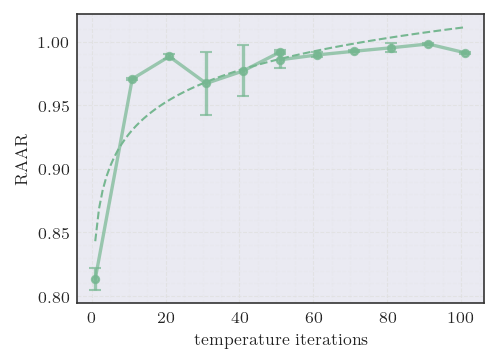

In [285]:
import styling
import matplotlib.pyplot as plt
import seaborn as sns

styling.set_my_style()

df = pd.DataFrame()
df["temperature iterations"] = temp_iterations
df["RAAR"] = mean_raar.squeeze()
df["RAAR_std"] = std_raar.squeeze()

palette = styling.shades(6, 4)[1:]
palette = sns.color_palette("crest", 5)


fig, ax = styling.subplots(figsize=(3.5, 2.5))

line = plt.plot(
    df["temperature iterations"],
    df["RAAR"],
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)


ax.errorbar(
    x=df["temperature iterations"],
    y=df["RAAR"],
    yerr=df["RAAR_std"],
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)

sns.regplot(x=df["temperature iterations"], y=df["RAAR"], color=palette[0], ax=ax, line_kws={'linestyle': "--", 'linewidth': 1.0}, ci=None, logx=True)

In [286]:
min_losses = loss_spaces.min(axis=1)
min_loss_candidates = np.array([data[data['loss'] == min_loss]['candidate'] for data, min_loss in zip(brute_force_data, min_losses)])

In [287]:
optimal_candidates_found = [np.count_nonzero(sorted_losses == min_loss, axis=0) for sorted_losses, min_loss in zip(result_tensor[:, :, :, 2], min_losses)]
p_star = [optimal_found / sorted_losses.shape[0] for optimal_found, sorted_losses in zip(optimal_candidates_found, result_tensor[:, :, :, 2])]

In [288]:
from metrics import min_tts
tts_ps = np.array([min_tts(p_s, return_tts_p=True)[2] for p_s in p_star])

In [289]:
mask = np.any(np.isfinite(tts_ps), axis=0)
non_inf_tts_ps = tts_ps[:, mask]

In [290]:
finite_mask = np.any(np.isfinite(non_inf_tts_ps), axis=-1, keepdims=True)

masked = np.ma.masked_invalid(non_inf_tts_ps)
mean_tts_ps = masked.mean(axis=0).data
std_tts_ps = masked.std(axis=0).data

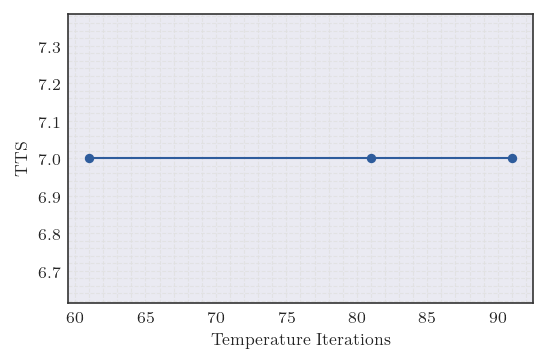

In [291]:
from matplotlib import pyplot as plt

plt.scatter(
    temp_iterations[mask],
    mean_tts_ps
)

plt.errorbar(
    temp_iterations[mask],
    y=mean_tts_ps,
    yerr=std_tts_ps,
)
plt.ylabel('TTS')
plt.xlabel('Temperature Iterations')
plt.grid(visible=True)